## ============================================================
## Notebook: 01_data_cleaning.ipynb
## ============================================================

### =========================
### 1. IMPORT LIBRARIES
### =========================

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### =========================
### 2. LOAD DATA
### =========================

In [2]:
#Load data
file_path = "../data/raw/online_retail_II.xlsx"
df_2009 = pd.read_excel(file_path,sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(file_path,sheet_name="Year 2010-2011")

# Merge data
df = pd.concat([df_2009, df_2010], ignore_index=True)

print("\nMerged Dataset Shape :", df.shape)


Merged Dataset Shape : (1067371, 8)


### =========================
### 3. INITIAL INSPECTION
### =========================

In [3]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB
None


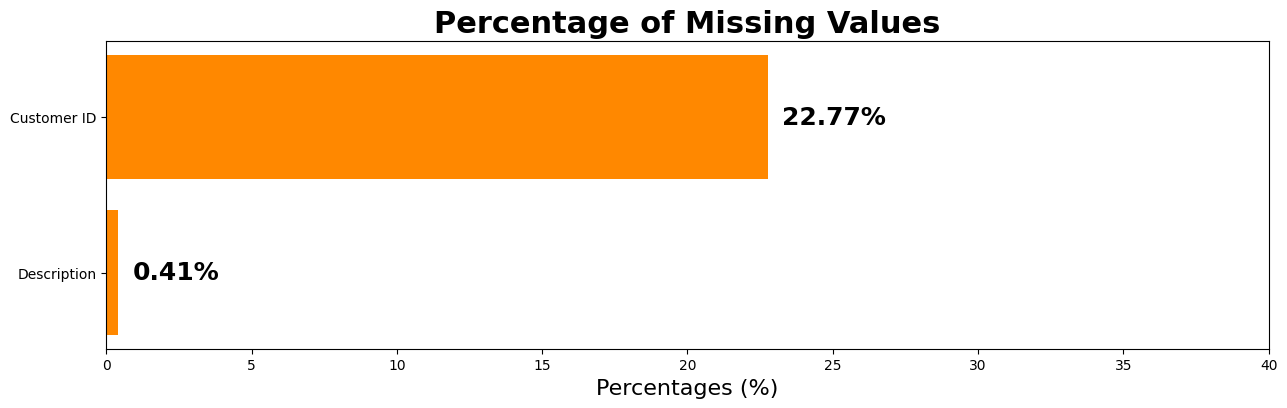

In [5]:
# Calculating the percentage of missing values for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

# Prepare values
missing_percentage.sort_values(ascending=True, inplace=True)

# Plot the barh chart
fig, ax = plt.subplots(figsize=(15, 4))
ax.barh(missing_percentage.index, missing_percentage, color="#ff8800")

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')

# Set x-axis limit
ax.set_xlim([0, 40])

# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

In [6]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 34335


### =========================
### 4. STANDARDIZE COLUMN NAMES
### =========================

In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
print("\nColumns:")
print(df.columns)


Columns:
Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country'],
      dtype='str')


### =========================
### 5. HANDLE MISSING VALUES
### =========================

customer_id (22.77% missing values)

- The customer_id column contains nearly a quarter of missing data.Imputing such a large percentage of missing values might introduce significant bias or noise into the analysis.

- Therefore, removing the rows with missing customer_ids seems to be the most reasonable approach to maintain the integrity of the clusters and the analysis.

description (0.41% missing values)

- The description column has a minor percentage of missing values. 

- Since the missing percentage is quite low, it would be prudent to remove the rows with missing Descriptions to avoid propagating errors and inconsistencies into the subsequent analyses.

By removing rows with missing values in the customer_id and description columns, we aim to construct a cleaner and more reliable dataset.
     
     
     

In [8]:
# Remove rows without customer_id
df = df.dropna(subset=["customer_id"])
# Remove rows without description
df = df.dropna(subset=["description"])

### =========================
### 6. REMOVING DUPLICATES
### =========================

In [9]:
df.drop_duplicates(inplace=True)

### =========================
### 7. CONVERT DATA TYPES
### =========================

In [10]:
# Convert invoice_date to datetime
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

# Convert customer_id to integer
df["customer_id"] = df["customer_id"].astype(int)

In [11]:
print("\nData Types:")
print(df.dtypes)


Data Types:
invoice                object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[us]
price                 float64
customer_id             int64
country                   str
dtype: object


### =========================
### 8. REMOVE CANCELED ORDERS
### =========================

In [12]:
# Canceled invoices usually start with "C"
df = df[~df["invoice"].astype(str).str.startswith("C")]

In [13]:
print("\nShape after removing canceled orders:")
print(df.shape)


Shape after removing canceled orders:
(779495, 8)


### =========================
### 9. FEATURE ENGINEERING
### =========================

In [14]:
# Total transaction value
df["total_price"] = df["quantity"] * df["price"]

# Year
df["year"] = df["invoicedate"].dt.year

# Month Number
df["month"] = df["invoicedate"].dt.month

# Month Name
df["month_name"] = df["invoicedate"].dt.month_name()

# Day
df["day"] = df["invoicedate"].dt.day

# Hour
df["hour"] = df["invoicedate"].dt.hour

# Day of Week
df["day_of_week"] = df["invoicedate"].dt.day_name()

# Year-Month
df["year_month"] = df["invoicedate"].dt.to_period("M").astype(str)

### =========================
### 10. REMOVE INVALID VALUES
### =========================

In [15]:
# Remove negative or zero quantity
df = df[df["quantity"] > 0]

# Remove negative or zero price
df = df[df["price"] > 0]

print("\nShape after removing invalid quantity/price:")
print(df.shape)


Shape after removing invalid quantity/price:
(779425, 16)


### =========================
### 11. OUTLIER HANDLING
### =========================

In [16]:
# Calculate percentile thresholds
q_low = df["total_price"].quantile(0.01)
q_high = df["total_price"].quantile(0.99)
q_extreme = df["total_price"].quantile(0.999)

print(f"Transaction value thresholds:")
print(f"   Bottom 1%: £{q_low:.2f}")
print(f"   Top 1%: £{q_high:.2f}")
print(f"   Extreme (>99.9%): £{q_extreme:.2f}")

Transaction value thresholds:
   Bottom 1%: £0.60
   Top 1%: £203.52
   Extreme (>99.9%): £864.00


In [17]:
# 11.1 Flag transaction types
df['transaction_type'] = 'Regular'


wholesale_conditions = (
    (df['total_price'] > q_high) |  # High transaction value
    (df['quantity'] > 200) |         # Bulk quantity purchase
    (df['price'] < 1.0)              # Wholesale pricing
)

df.loc[wholesale_conditions, 'transaction_type'] = 'Wholesale'

df.loc[df['total_price'] > q_extreme, 'transaction_type'] = 'Bulk Corporate'

In [18]:
# 11.2 Flag small/test transactions 
df['is_test_transaction'] = (
    (df['total_price'] < 1.0) &  # Very small amounts
    (df['quantity'] == 1)         # Single item
)

In [19]:
# 11.3 Create customer-level aggregation for wholesale flag
customer_wholesale = df.groupby('customer_id')['transaction_type'].apply(
    lambda x: 'Wholesale' if (x == 'Wholesale').any() else 'Retail'
).reset_index()
customer_wholesale.columns = ['customer_id', 'customer_type']

# Merge back to main dataframe
df = df.merge(customer_wholesale, on='customer_id', how='left')

In [20]:
# 11.4 Statistical summary of outlier handling
print(f"\n📊 Outlier Classification Summary:")
print(f"   Regular transactions: {(df['transaction_type'] == 'Regular').sum():,}")
print(f"   Wholesale transactions: {(df['transaction_type'] == 'Wholesale').sum():,}")
print(f"   Bulk Corporate transactions: {(df['transaction_type'] == 'Bulk Corporate').sum():,}")
print(f"   Test/small transactions flagged: {df['is_test_transaction'].sum():,}")


📊 Outlier Classification Summary:
   Regular transactions: 599,541
   Wholesale transactions: 179,108
   Bulk Corporate transactions: 776
   Test/small transactions flagged: 17,853


In [21]:
# 11.5 Show revenue contribution by transaction type
revenue_by_type = df.groupby('transaction_type').agg({
    'total_price': ['sum', 'count', 'mean']
}).round(2)
revenue_by_type.columns = ['total_revenue', 'transaction_count', 'avg_value']
print(f"\n💰 Revenue by Transaction Type:")
print(revenue_by_type)


💰 Revenue by Transaction Type:
                  total_revenue  transaction_count  avg_value
transaction_type                                             
Bulk Corporate       1559696.80                776    2009.92
Regular             11527172.62             599541      19.23
Wholesale            4287934.85             179108      23.94


In [22]:
# 11.6 For churn/CLV modeling
print(f"\n✅ Outliers categorized but NOT dropped - preserving all customer behavior!")


✅ Outliers categorized but NOT dropped - preserving all customer behavior!


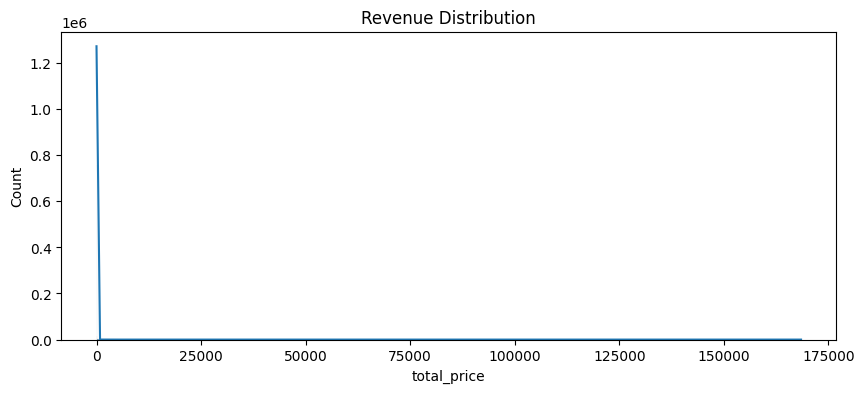

In [23]:
# DISTRIBUTION CHECK (New step for ML readiness)
plt.figure(figsize=(10, 4))
sns.histplot(df['total_price'], kde=True)
plt.title("Revenue Distribution")
plt.show()

In [24]:
print("\nQuantity Statistics:")
display(df["quantity"].describe())


Quantity Statistics:


count    779425.000000
mean         13.489370
std         145.855814
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: quantity, dtype: float64

### =============================================
### 12. CREATE DIMENSION TABLES FOR STAR SCHEMA
### =============================================

In [25]:
# 12.1 Create Product Dimension Table
dim_product = df[['stockcode', 'description']].drop_duplicates(subset=['stockcode']).copy()
dim_product['stockcode'] = dim_product['stockcode'].astype(str)
dim_product = dim_product.sort_values('stockcode').reset_index(drop=True)


In [26]:
def categorize_product(description):
    if pd.isna(description):
        return 'Unknown'
    desc_upper = str(description).upper()
    if any(keyword in desc_upper for keyword in ['CHRISTMAS', 'EASTER', 'HALLOWEEN', 'SEASONAL']):
        return 'Seasonal'
    elif any(keyword in desc_upper for keyword in ['DECOR', 'FRAME', 'LIGHT', 'CANDLE', 'VASE', 'MIRROR']):
        return 'Home Decor'
    elif any(keyword in desc_upper for keyword in ['MUG', 'CUP', 'PLATE', 'BOWL', 'JAR', 'STORAGE']):
        return 'Kitchen'
    elif any(keyword in desc_upper for keyword in ['GARDEN', 'PLANT', 'FLOWER', 'OUTDOOR']):
        return 'Garden'
    elif any(keyword in desc_upper for keyword in ['TOY', 'GAME', 'DOLL', 'PUZZLE']):
        return 'Toys'
    elif any(keyword in desc_upper for keyword in ['ART', 'PAINTING', 'PHOTO', 'PRINT']):
        return 'Art'
    elif any(keyword in desc_upper for keyword in ['CHAIR', 'TABLE', 'DESK', 'SHELF', 'RACK']):
        return 'Furniture'
    else:
        return 'Other'

dim_product['product_category'] = dim_product['description'].apply(categorize_product)


In [27]:
# 13.2 Create Date Dimension Table
unique_dates = pd.Series(df['invoicedate'].dt.date.unique())
unique_dates = pd.to_datetime(unique_dates).sort_values()

dim_date = pd.DataFrame({'date': unique_dates})
dim_date['date_key'] = dim_date['date'].dt.strftime('%Y%m%d').astype(int)
dim_date['year'] = dim_date['date'].dt.year
dim_date['quarter'] = dim_date['date'].dt.quarter
dim_date['month'] = dim_date['date'].dt.month
dim_date['month_name'] = dim_date['date'].dt.month_name()
dim_date['day'] = dim_date['date'].dt.day
dim_date['day_of_week'] = dim_date['date'].dt.dayofweek
dim_date['day_name'] = dim_date['date'].dt.day_name()
dim_date['week_of_year'] = dim_date['date'].dt.isocalendar().week
dim_date['is_weekend'] = (dim_date['day_of_week'] >= 5).astype(int)
dim_date['year_month'] = dim_date['date'].dt.strftime('%Y-%m')
dim_date['year_quarter'] = dim_date['year'].astype(str) + '-Q' + dim_date['quarter'].astype(str)


In [28]:
# 13.3 Save all tables (Fact + Dimensions)
output_path = "../data/processed/cleaned_transactions.csv"
df.to_csv(output_path, index=False)
print(f"✅ Fact table saved to: {output_path}")

# Product Dimension
dim_product.to_csv("../data/processed/dim_product.csv", index=False)
print(f"✅ Product dimension saved to: ../data/processed/dim_product.csv")

# Date Dimension
dim_date.to_csv("../data/processed/dim_date.csv", index=False)
print(f"✅ Date dimension saved to: ../data/processed/dim_date.csv")
print("\n🎯 Star Schema Ready: Fact + Product + Date dimensions exported!")

✅ Fact table saved to: ../data/processed/cleaned_transactions.csv
✅ Product dimension saved to: ../data/processed/dim_product.csv
✅ Date dimension saved to: ../data/processed/dim_date.csv

🎯 Star Schema Ready: Fact + Product + Date dimensions exported!


### =========================
### 13. FINAL DATA CHECK
### =========================

In [29]:
print("\nFinal Dataset Shape:", df.shape)


Final Dataset Shape: (779425, 19)


In [30]:
print("\nFinal Missing Values:")
print(df.isnull().sum())


Final Missing Values:
invoice                0
stockcode              0
description            0
quantity               0
invoicedate            0
price                  0
customer_id            0
country                0
total_price            0
year                   0
month                  0
month_name             0
day                    0
hour                   0
day_of_week            0
year_month             0
transaction_type       0
is_test_transaction    0
customer_type          0
dtype: int64


In [31]:
print("\nFinal Preview:")
display(df.head())


Final Preview:


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,total_price,year,month,month_name,day,hour,day_of_week,year_month,transaction_type,is_test_transaction,customer_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,December,1,7,Tuesday,2009-12,Regular,False,Wholesale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,1,7,Tuesday,2009-12,Regular,False,Wholesale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,1,7,Tuesday,2009-12,Regular,False,Wholesale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,December,1,7,Tuesday,2009-12,Regular,False,Wholesale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,December,1,7,Tuesday,2009-12,Regular,False,Wholesale


In [32]:
print("\n================ BUSINESS SUMMARY ================")

print(f"Total Transactions : {len(df):,}")

print(f"Total Customers    : {df['customer_id'].nunique():,}")

print(f"Total Products     : {df['stockcode'].nunique():,}")

print(f"Total Revenue      : ${df['total_price'].sum():,.2f}")

print(f"Countries Covered  : {df['country'].nunique():,}")

print("==================================================")


================ BUSINESS SUMMARY ================
Total Transactions : 779,425
Total Customers    : 5,878
Total Products     : 4,631
Total Revenue      : $17,374,804.27
Countries Covered  : 41
